## 1 | Datensatz kurz vorgestellt

Quelle: Fake News Detection Datasets (Kaggle-Link oben).

Dateien: Fake.csv (≈ 23 481 Zeilen) und True.csv (≈ 21 417 Zeilen) – jeweils mit den Spalten title, text, subject, date Kaggle
Label: Wir fügen eine Binär-Spalte label hinzu (0 = fake, 1 = true) und legen beide Dateien zu einem Data-Frame df zusammen.

In [11]:
pip install -r requirements.txt --break-system-packages

Note: you may need to restart the kernel to use updated packages.


## 2 | Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns 
fake  = pd.read_csv("data/Fake.csv")
true  = pd.read_csv("data/True.csv")
fake["label"], true["label"] = 0, 1
df = pd.concat([fake, true]).sample(frac=1).reset_index(drop=True)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [6]:
df.label.value_counts(normalize=True)

label
0    0.522985
1    0.477015
Name: proportion, dtype: float64

<Axes: xlabel='subject'>

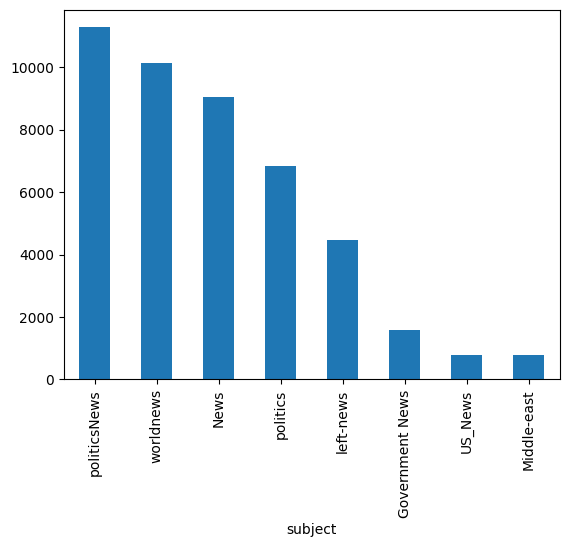

In [7]:
df.subject.value_counts().plot.bar()

<Axes: xlabel='num_words', ylabel='Count'>

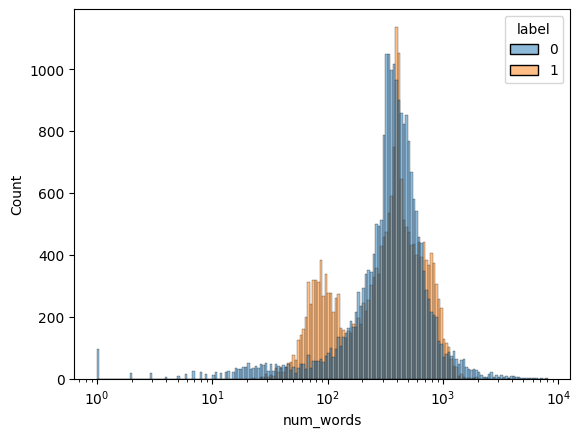

In [8]:
df["num_words"] = df.text.str.split().str.len()
sns.histplot(data=df, x="num_words", hue="label", log_scale=True)

<Axes: xlabel='date'>

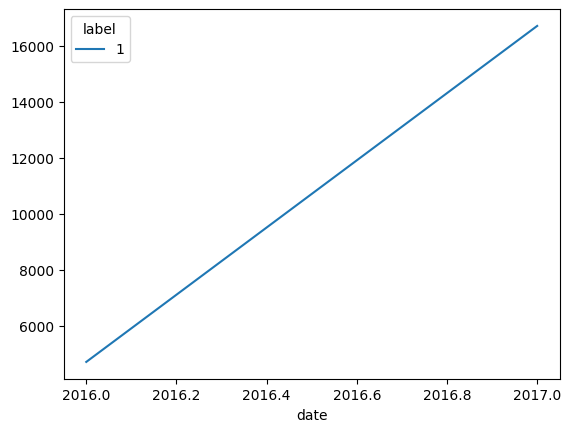

In [9]:
df.date = pd.to_datetime(df.date, errors="coerce")
df.groupby([df.date.dt.year,"label"]).size().unstack().plot()

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(1,2), stop_words="english")

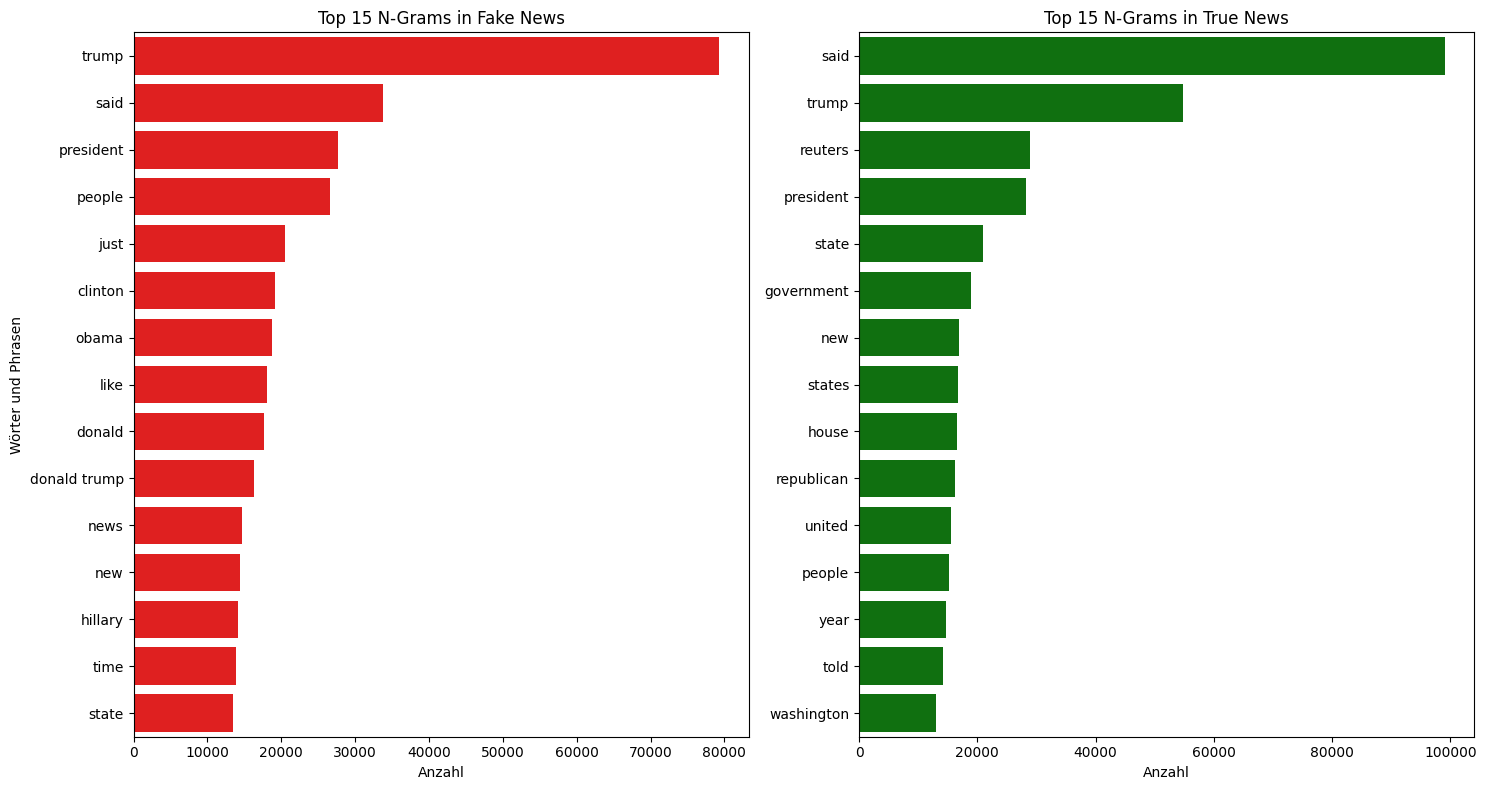

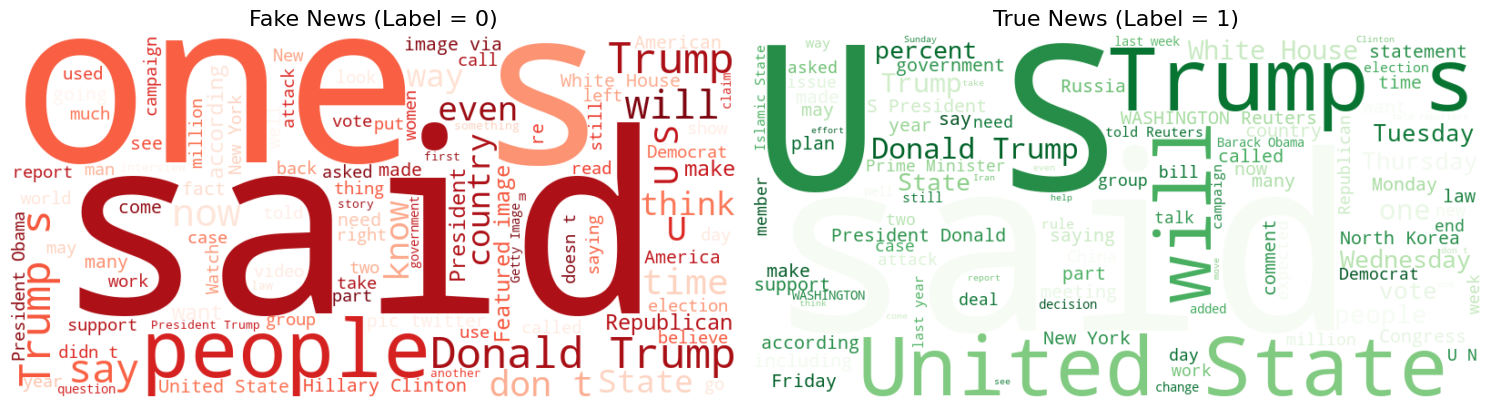

In [12]:
# Wende CountVectorizer auf die Textspalte an
X = cv.fit_transform(df['text'])
feature_names = cv.get_feature_names_out()

# Funktion zur Extraktion der häufigsten Wörter pro Label
def get_top_n_words(corpus, labels, label_value, n=20):
    # Filtere die Dokumente nach dem Label
    indices = [i for i, l in enumerate(labels) if l == label_value]
    # Summiere die Features über alle Dokumente mit diesem Label
    if indices:
        sums = X[indices].sum(axis=0)
        data = []
        for col, term in enumerate(feature_names):
            data.append((term, sums[0, col]))
        ranking = pd.DataFrame(data, columns=['term', 'count'])
        return ranking.sort_values('count', ascending=False).head(n)
    return pd.DataFrame()

# Hole Top-Wörter für jedes Label
top_fake = get_top_n_words(X, df['label'], 0, 15)
top_true = get_top_n_words(X, df['label'], 1, 15)

# Visualisierung mit Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Top Wörter für Fake News
sns.barplot(x='count', y='term', data=top_fake, ax=ax1, color='red')
ax1.set_title('Top 15 N-Grams in Fake News')
ax1.set_xlabel('Anzahl')
ax1.set_ylabel('Wörter und Phrasen')

# Top Wörter für True News
sns.barplot(x='count', y='term', data=top_true, ax=ax2, color='green')
ax2.set_title('Top 15 N-Grams in True News')
ax2.set_xlabel('Anzahl')
ax2.set_ylabel('')  # Nur eine Y-Achsenbeschriftung ist ausreichend

plt.tight_layout()
plt.show()

# Optional: Wordclouds für True und Fake News
from wordcloud import WordCloud

plt.figure(figsize=(15, 6))

# Wordcloud für Fake News
plt.subplot(1, 2, 1)
fake_text = ' '.join(df[df['label'] == 0]['text'])
wordcloud_fake = WordCloud(background_color='white', max_words=100, 
                          colormap='Reds', width=800, height=400).generate(fake_text)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Fake News (Label = 0)', fontsize=16)

# Wordcloud für True News
plt.subplot(1, 2, 2)
true_text = ' '.join(df[df['label'] == 1]['text'])
wordcloud_true = WordCloud(background_color='white', max_words=100, 
                          colormap='Greens', width=800, height=400).generate(true_text)
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.axis('off')
plt.title('True News (Label = 1)', fontsize=16)

plt.tight_layout()
plt.show()

<Figure size 1400x700 with 0 Axes>

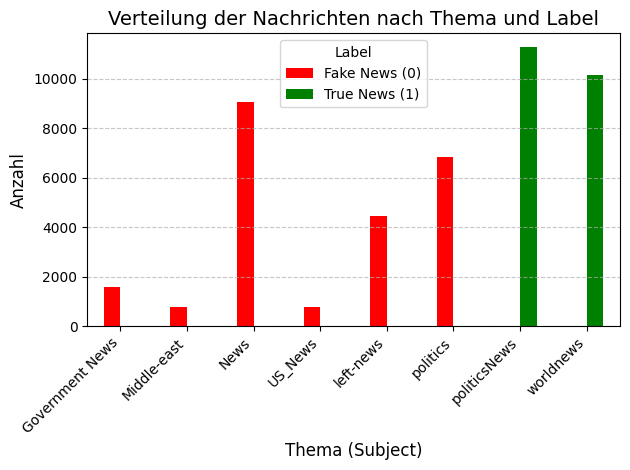

<Figure size 1400x700 with 0 Axes>

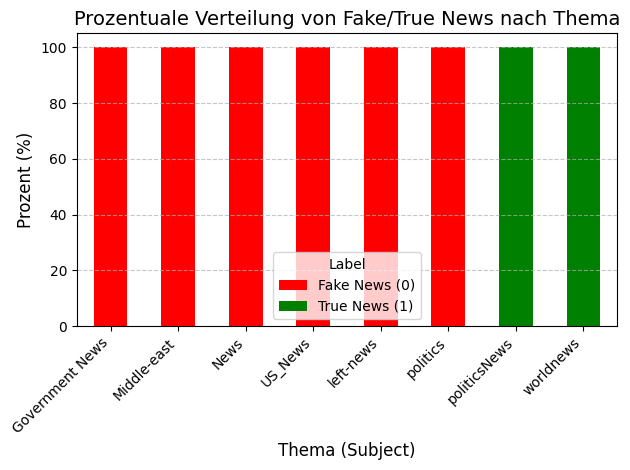

In [13]:
# Variante 1: Gruppiertes Balkendiagramm nach subject und label
plt.figure(figsize=(14, 7))

# Kreuztabelle erstellen
subject_label_counts = pd.crosstab(df['subject'], df['label'])

# Spalten umbenennen für bessere Lesbarkeit
subject_label_counts.columns = ['Fake News (0)', 'True News (1)']

# Gruppiertes Balkendiagramm erstellen
subject_label_counts.plot(kind='bar', color=['red', 'green'])

# Diagramm-Titel und Beschriftungen
plt.title('Verteilung der Nachrichten nach Thema und Label', fontsize=14)
plt.xlabel('Thema (Subject)', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Variante 2: Prozentuale Verteilung (kann aufschlussreicher sein)
plt.figure(figsize=(14, 7))

# Prozentuale Verteilung innerhalb jedes Subjects
subject_label_percent = pd.crosstab(df['subject'], df['label'], normalize='index') * 100
subject_label_percent.columns = ['Fake News (0)', 'True News (1)']

# Gestapeltes Balkendiagramm
subject_label_percent.plot(kind='bar', stacked=True, color=['red', 'green'])

plt.title('Prozentuale Verteilung von Fake/True News nach Thema', fontsize=14)
plt.xlabel('Thema (Subject)', fontsize=12)
plt.ylabel('Prozent (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

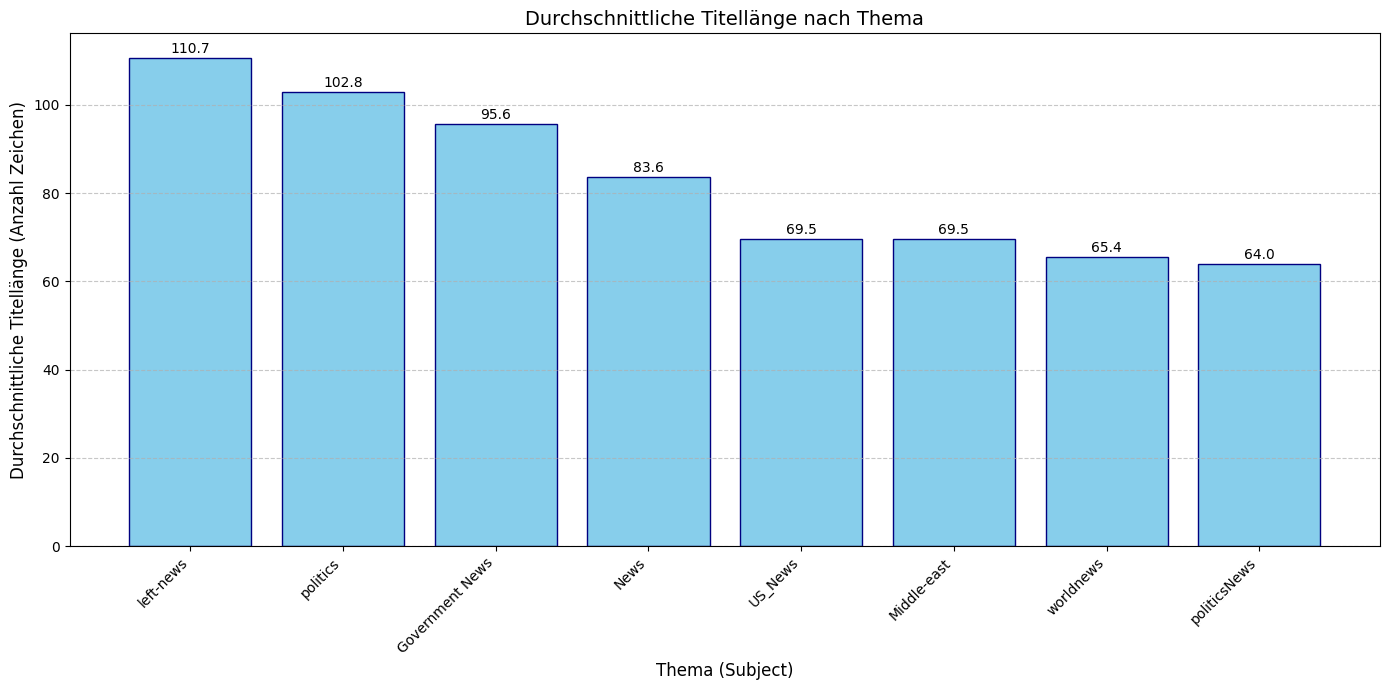

<Figure size 1400x700 with 0 Axes>

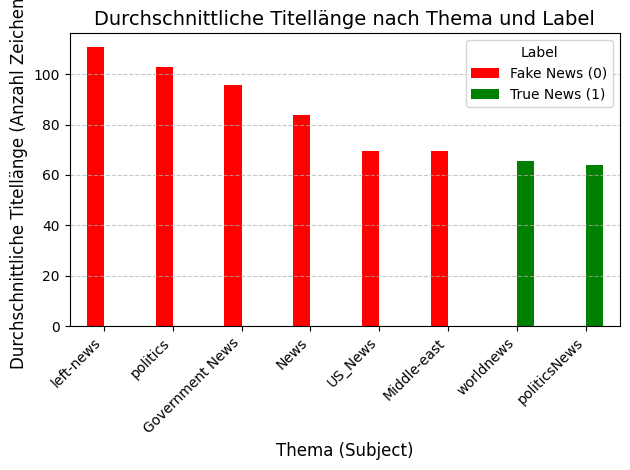

In [15]:
# Titellänge berechnen und als neue Spalte hinzufügen
df['title_length'] = df['title'].str.len()

# Variante 1: Durchschnittliche Titellänge pro Thema
plt.figure(figsize=(14, 7))

# Gruppieren nach Subject und Durchschnitt berechnen
title_length_by_subject = df.groupby('subject')['title_length'].mean().sort_values(ascending=False)

# Balkendiagramm erstellen
bars = plt.bar(title_length_by_subject.index, title_length_by_subject.values, color='skyblue', edgecolor='navy')

# Werte über den Balken anzeigen
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10)

# Diagramm-Titel und Beschriftungen
plt.title('Durchschnittliche Titellänge nach Thema', fontsize=14)
plt.xlabel('Thema (Subject)', fontsize=12)
plt.ylabel('Durchschnittliche Titellänge (Anzahl Zeichen)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Variante 2: Titellänge nach Thema und Label (Fake vs. True)
plt.figure(figsize=(14, 7))

# Durchschnittliche Titellänge nach Subject und Label
title_length_by_subject_label = df.groupby(['subject', 'label'])['title_length'].mean().unstack()
title_length_by_subject_label.columns = ['Fake News (0)', 'True News (1)']

# Sortieren nach Gesamtdurchschnitt
title_length_by_subject = df.groupby('subject')['title_length'].mean().sort_values(ascending=False)
sorted_index = title_length_by_subject.index

# Gruppiertes Balkendiagramm erstellen
title_length_by_subject_label.loc[sorted_index].plot(kind='bar', color=['red', 'green'])

# Diagramm-Titel und Beschriftungen
plt.title('Durchschnittliche Titellänge nach Thema und Label', fontsize=14)
plt.xlabel('Thema (Subject)', fontsize=12)
plt.ylabel('Durchschnittliche Titellänge (Anzahl Zeichen)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Anzahl der signifikanten Unterschiede: 27 von 28


,Vergleich,T-Wert,p-Wert,p-Wert (korrigiert),Signifikant
0,politicsNews vs politics,-103.921232,0.000000e+00,0.000000e+00,True
2,politicsNews vs News,-126.714162,0.000000e+00,0.000000e+00,True
23,worldnews vs left-news,-95.088536,0.000000e+00,0.000000e+00,True
5,politicsNews vs left-news,-98.718414,0.000000e+00,0.000000e+00,True
8,politics vs News,49.495225,0.000000e+00,0.000000e+00,True
9,politics vs worldnews,99.121663,0.000000e+00,0.000000e+00,True
20,News vs left-news,-55.872877,0.000000e+00,0.000000e+00,True
18,News vs worldnews,111.742866,0.000000e+00,0.000000e+00,True
16,US_News vs left-news,-49.203069,1.086944e-321,3.379409e-321,True
25,Middle-east vs left-news,-49.131329,6.045387e-320,1.692718e-319,True


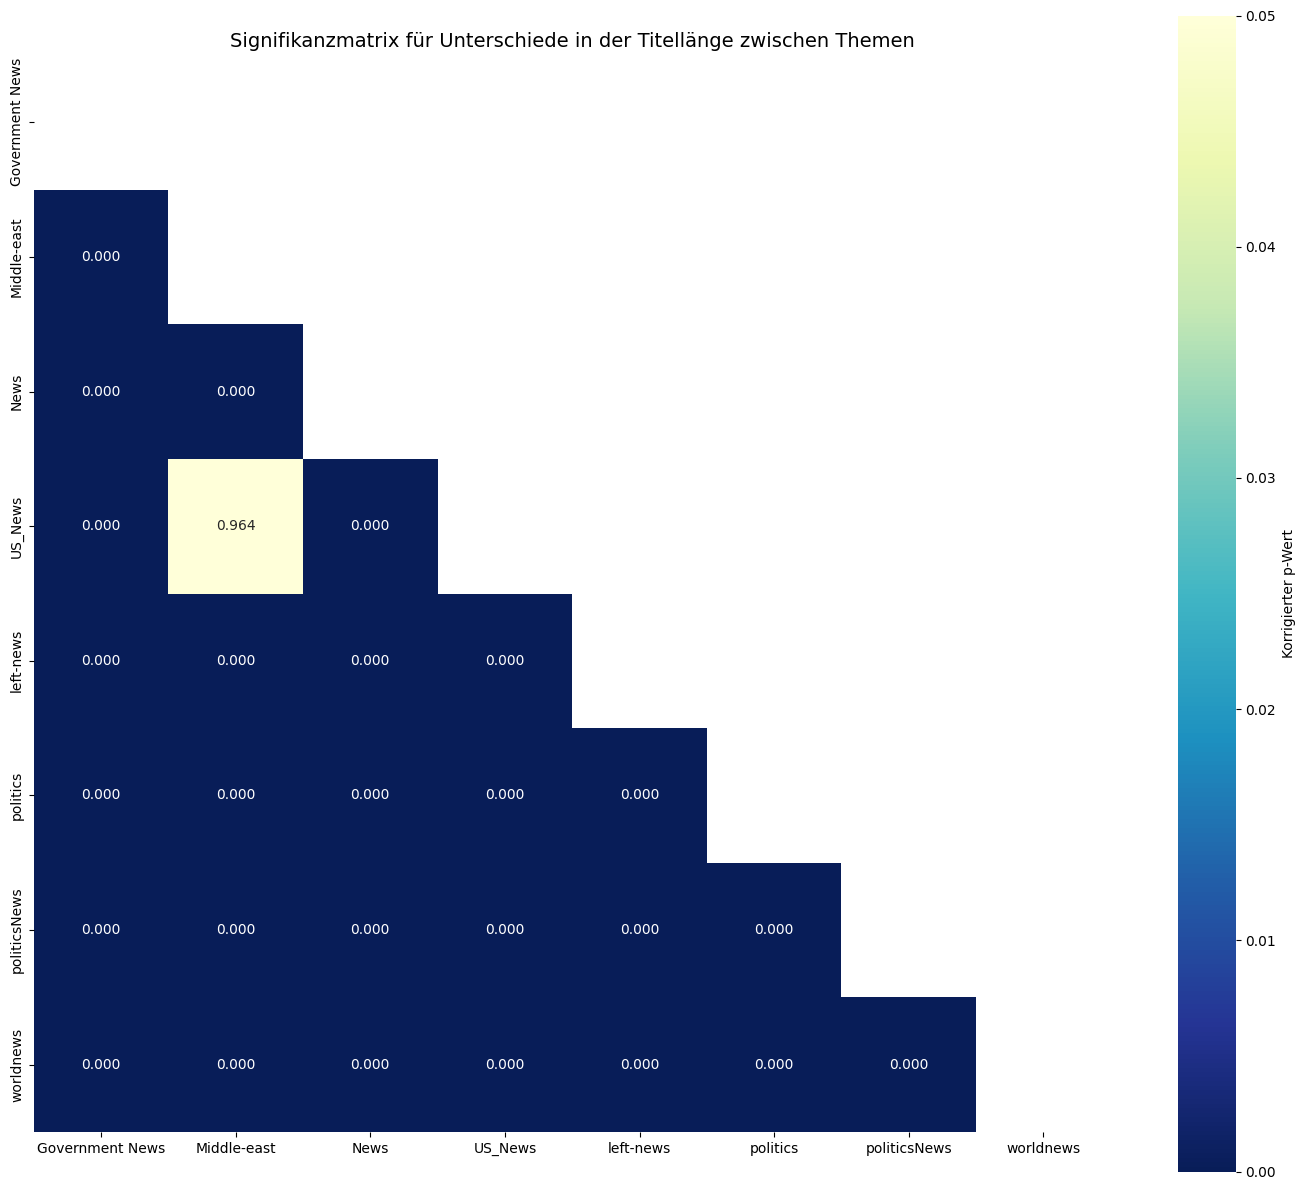

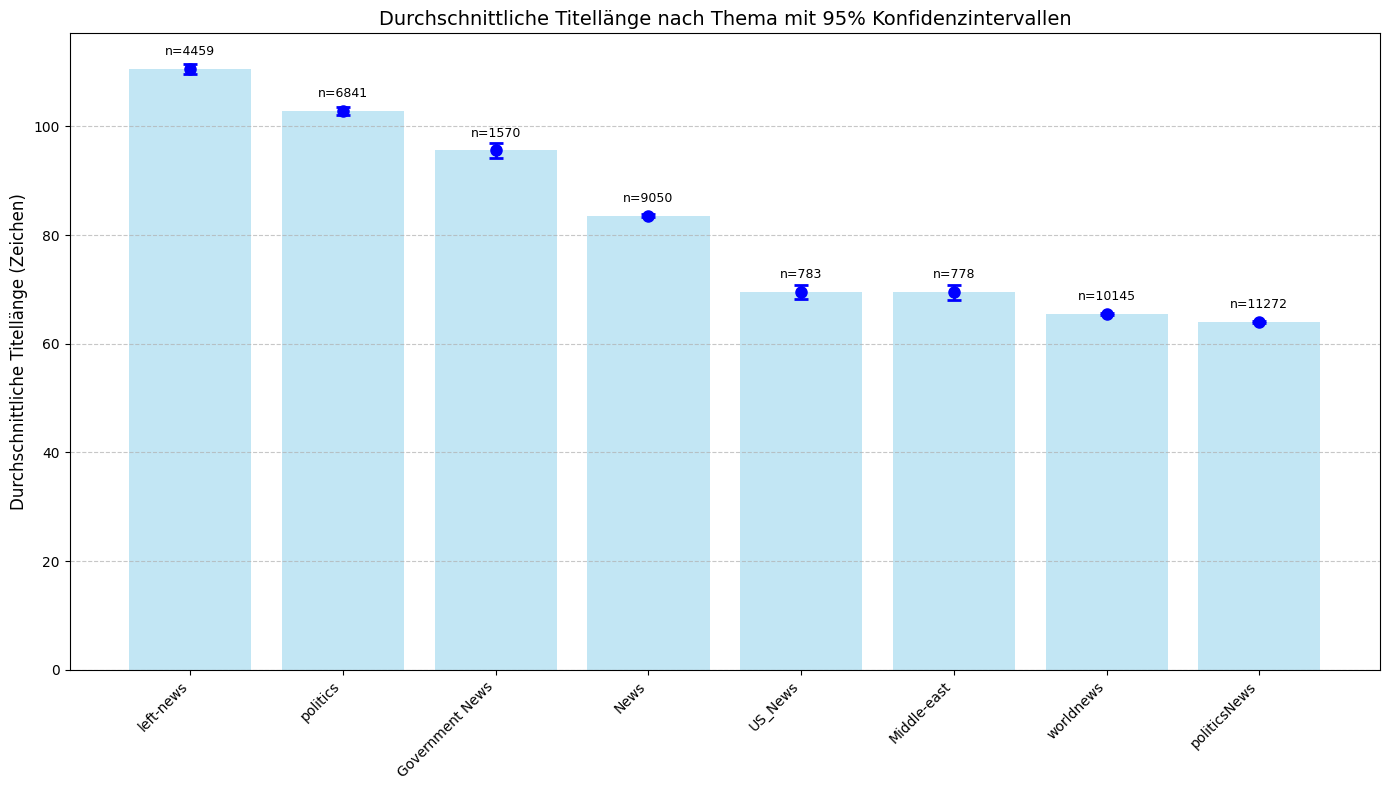

In [16]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np
import itertools

# Funktion für den T-Test mit Korrektur für multiple Vergleiche
def perform_multiple_ttests_with_correction(df, correction_method='fdr_bh'):
    # Alle einzigartigen Subjects bekommen
    subjects = df['subject'].unique()
    
    # Listen für die Ergebnisse vorbereiten
    pairs = []
    t_stats = []
    p_values = []
    
    # Alle Paare von Subjects durchlaufen und T-Tests durchführen
    for s1, s2 in itertools.combinations(subjects, 2):
        # Daten für jedes Thema extrahieren
        data1 = df[df['subject'] == s1]['title_length']
        data2 = df[df['subject'] == s2]['title_length']
        
        # T-Test durchführen
        t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test (ungleiche Varianzen)
        
        # Ergebnisse speichern
        pairs.append(f"{s1} vs {s2}")
        t_stats.append(t_stat)
        p_values.append(p_val)
    
    # Korrektur für multiple Vergleiche
    reject, p_corrected, _, _ = multipletests(p_values, method=correction_method)
    
    # Ergebnisse in DataFrame organisieren
    results_df = pd.DataFrame({
        'Vergleich': pairs,
        'T-Wert': t_stats,
        'p-Wert': p_values,
        'p-Wert (korrigiert)': p_corrected,
        'Signifikant': reject
    })
    
    # Nach korrigierten p-Werten sortieren
    results_df = results_df.sort_values('p-Wert (korrigiert)')
    
    return results_df

# T-Tests durchführen mit FDR-Korrektur (Benjamini-Hochberg)
results = perform_multiple_ttests_with_correction(df, correction_method='fdr_bh')

# Ergebnisse anzeigen
print(f"Anzahl der signifikanten Unterschiede: {results['Signifikant'].sum()} von {len(results)}")
display(results)

# Heatmap der p-Werte erstellen
plt.figure(figsize=(14, 12))

# Matrix für alle Subject-Kombinationen erstellen
subjects = sorted(df['subject'].unique())
n_subjects = len(subjects)
p_matrix = np.ones((n_subjects, n_subjects))

# p-Werte in die Matrix füllen
for idx, row in results.iterrows():
    s1, s2 = row['Vergleich'].split(' vs ')
    i, j = subjects.index(s1), subjects.index(s2)
    p_matrix[i, j] = p_matrix[j, i] = row['p-Wert (korrigiert)']

# Heatmap erstellen
mask = np.triu(np.ones_like(p_matrix, dtype=bool))  # Oberes Dreieck maskieren
sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='YlGnBu_r',
            xticklabels=subjects, yticklabels=subjects, vmax=0.05, vmin=0, square=True, cbar_kws={'label': 'Korrigierter p-Wert'})

plt.title('Signifikanzmatrix für Unterschiede in der Titellänge zwischen Themen', fontsize=14)
plt.tight_layout()
plt.show()

# Visualisierung der durchschnittlichen Titellängen mit Konfidenzintervallen
plt.figure(figsize=(14, 8))

# Daten vorbereiten
subject_stats = []
for subject in subjects:
    data = df[df['subject'] == subject]['title_length']
    mean = data.mean()
    # 95% Konfidenzintervall berechnen
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    subject_stats.append({
        'subject': subject,
        'mean': mean,
        'ci_low': ci[0],
        'ci_high': ci[1],
        'count': len(data)
    })

# In DataFrame umwandeln und nach Mittelwert sortieren
stats_df = pd.DataFrame(subject_stats).sort_values('mean', ascending=False)

# Balkendiagramm mit Fehlerbalken erstellen
plt.errorbar(x=range(len(stats_df)), y=stats_df['mean'], 
             yerr=[(stats_df['mean']-stats_df['ci_low']), (stats_df['ci_high']-stats_df['mean'])],
             fmt='o', capsize=5, capthick=2, elinewidth=2, markersize=8, color='blue')

# Balken hinzufügen
bars = plt.bar(range(len(stats_df)), stats_df['mean'], alpha=0.5, color='skyblue')

# Achsenbeschriftungen und Titel
plt.xticks(range(len(stats_df)), stats_df['subject'], rotation=45, ha='right')
plt.title('Durchschnittliche Titellänge nach Thema mit 95% Konfidenzintervallen', fontsize=14)
plt.ylabel('Durchschnittliche Titellänge (Zeichen)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Anzahl der Artikel pro Thema als Text hinzufügen
for i, bar in enumerate(bars):
    plt.text(i, bar.get_height() + 2, f"n={stats_df.iloc[i]['count']}", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()